In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
%pip install kagglehub

In [14]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path , "AB_NYC_2019.csv"))
df.head()


Path to dataset files: C:\Users\AH\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [16]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [17]:
df.shape

(48895, 16)

In [18]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

# Exploratory Data Analysis (EDA)

In [19]:
missing  = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

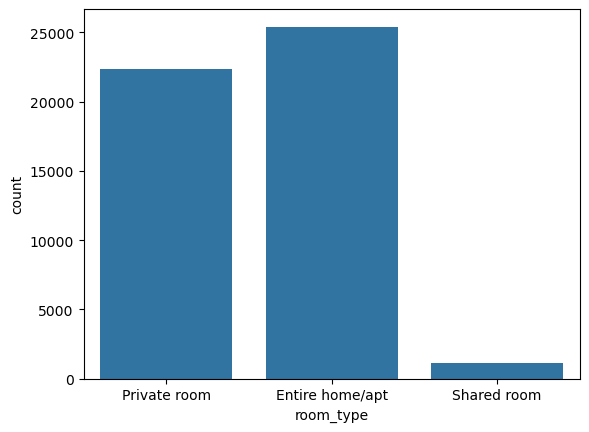

In [20]:
df['room_type'].value_counts()
sns.countplot(x = "room_type" , data=df)

In [21]:
numeric_df = df.select_dtypes(include = 'number').columns
numeric_df

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

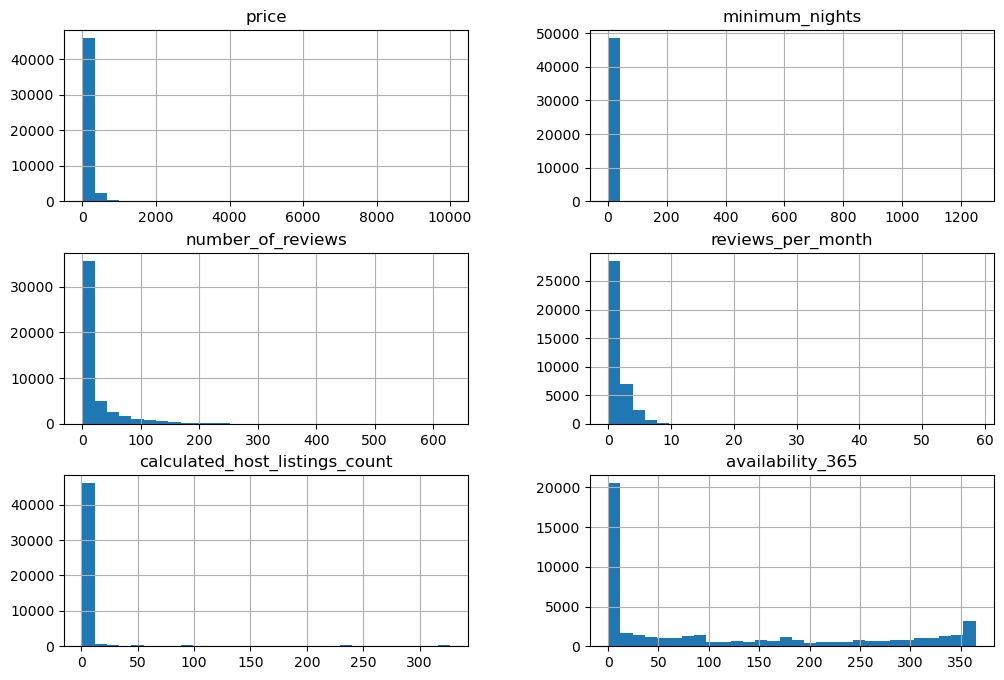

In [22]:
numeric_col = [  'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']
df[numeric_col].hist(bins= 30 , figsize=(12 ,8))


<Axes: xlabel='neighbourhood_group', ylabel='count'>

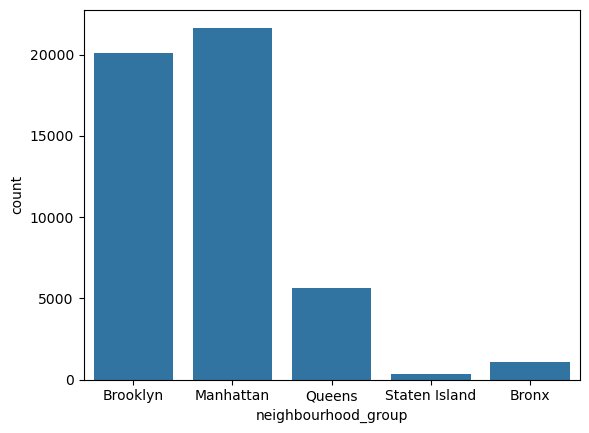

In [23]:
sns.countplot(x = "neighbourhood_group" , data= df)

<Axes: xlabel='room_type', ylabel='price'>

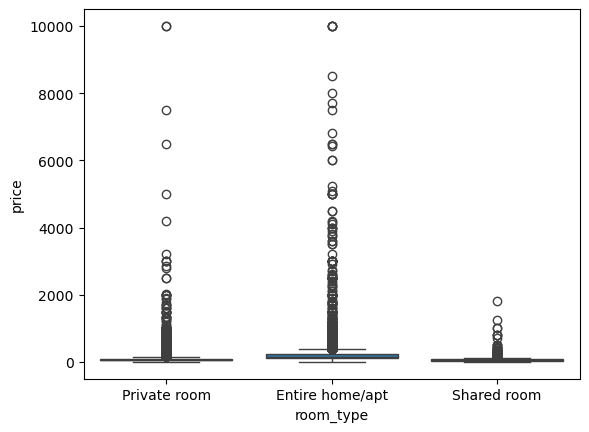

In [24]:
sns.boxplot(x = "room_type" , y= "price", data = df)

<Axes: >

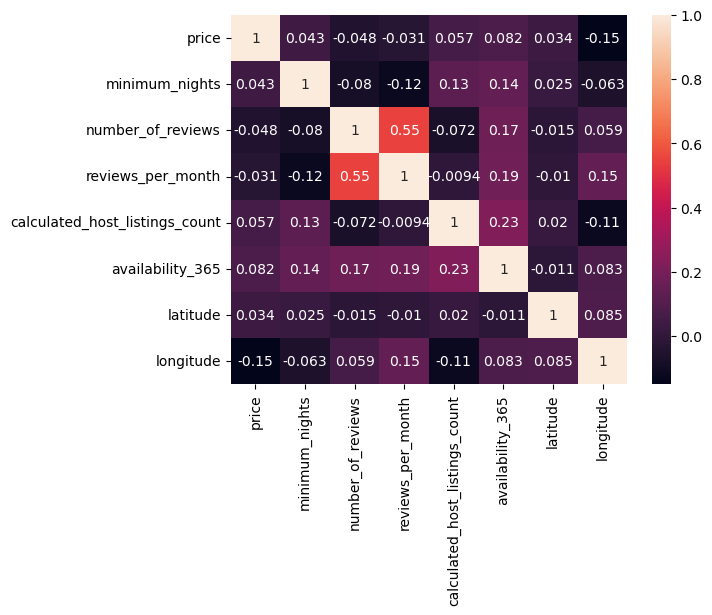

In [25]:
corr = df[numeric_col +['latitude', 'longitude']].corr()
sns.heatmap(corr,annot=True)

<Axes: xlabel='latitude', ylabel='longitude'>

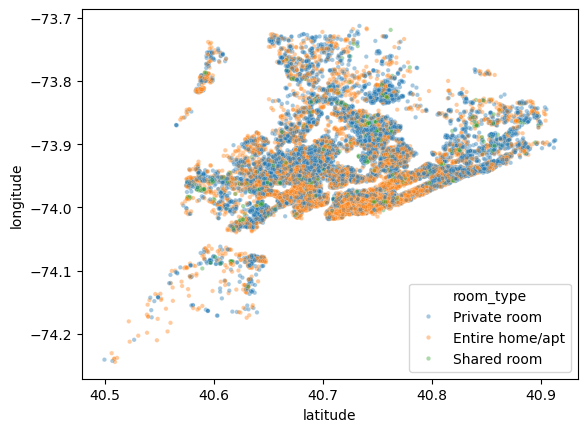

In [26]:
sns.scatterplot(x = "latitude" , y = 'longitude' ,data= df , hue ="room_type" , alpha=0.4, s=10)

# Data Cleaning & Feature Engineering

In [27]:
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [28]:
#1. Drop Colunmns that dont help us.

df_cleaned = df.drop(columns=["id" ,"name" ,"host_id" ,"host_name" ,"last_review"])

In [29]:
#2. No reviews yet -> 0 reviews per month, not missing
df_cleaned["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [30]:
#3. Cap Extreme outliers instead of deleting rows.

price_cap = df_cleaned['price'].quantile(0.99)
night_cap = df_cleaned["minimum_nights"].quantile(0.99)

df_cleaned['price'] = df_cleaned['price'].clip(upper =price_cap)
df_cleaned["minimum_nights"] =  df_cleaned["minimum_nights"].clip(upper = night_cap)


# df_clean = df_clean[df_clean['price'] < price_cap]
# df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]


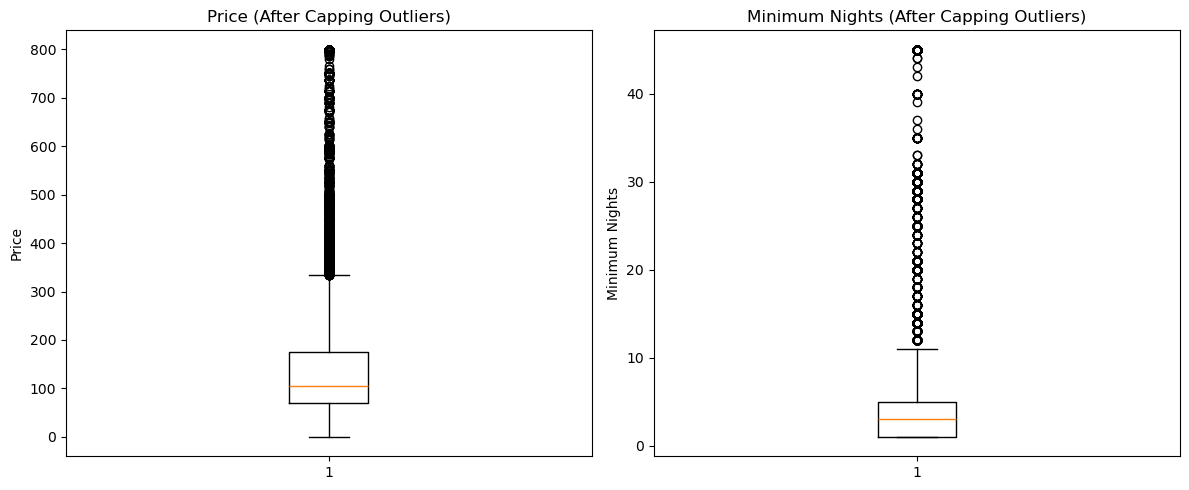

In [31]:

# Pehle ek copy save kar lo original data ki (clipping se pehle)
# maan lo aapke paas 'df_original' hai jisme clipping nahi hui thi

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for price
axes[0].boxplot(df_cleaned['price'])
axes[0].set_title('Price (After Capping Outliers)')
axes[0].set_ylabel('Price')

# Boxplot for minimum_nights
axes[1].boxplot(df_cleaned['minimum_nights'])
axes[1].set_title('Minimum Nights (After Capping Outliers)')
axes[1].set_ylabel('Minimum Nights')

plt.tight_layout()
plt.show()

In [32]:
Q1 = df_cleaned['price'].quantile(0.25)
Q3 = df_cleaned['price'].quantile(0.75)
IQR = Q3 - Q1
boxplot_cutoff = Q3 + 1.5 * IQR

print("99th percentile cap:", price_cap)
print("Boxplot's own outlier cutoff:", boxplot_cutoff)

99th percentile cap: 799.0
Boxplot's own outlier cutoff: 334.0


In [33]:
X = df_cleaned.drop(columns= ["room_type"])
y = df_cleaned["room_type"]

# Train / Test Split

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)
#Stratisfy ye ensure krta hai ki jab bhi hum split ya sample kare , har group(class) ka Original Propotion maintain rahe.

# Preprocessing: ColumnTransformer + Pipeline

In [36]:
import warnings
warnings.filterwarnings('ignore')

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OneHotEncoder , PowerTransformer
from sklearn.compose import ColumnTransformer     

In [38]:

numeric_col = [  'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']

categoric_col = ["neighbourhood_group","neighbourhood"]

#1. Pipeline -> for Numeric Columns
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])
#2. pipline -> for categorical columns

categoric_pipline = Pipeline(steps = [
    ('impute' , SimpleImputer(strategy= "most_frequent")),
   ( 'onehot'  , OneHotEncoder(handle_unknown= 'ignore')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_pipeline, numeric_col),
        ("categorical", categoric_pipline, categoric_col)
    ]
)
preprocessor     

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [39]:
df_cleaned["room_type"].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier

In [41]:
models= {
  'Logistic Regression':LogisticRegression(class_weight= "balanced" ,random_state= 42),
  'DecisionTreeClassifier':DecisionTreeClassifier(class_weight= "balanced" ,random_state= 42),
  'RandomForestClassifier':RandomForestClassifier(class_weight= "balanced" ,random_state= 42),
  'GradientBoostingClassifier':GradientBoostingClassifier(random_state= 42)
}

for name ,model in models.items():
    pipe = Pipeline(steps = [("preprocessor" ,preprocessor),("model" , model)])

    accuracy = cross_val_score(pipe, X_train, y_train, cv =3 , scoring = "accuracy")
    macrof1 =cross_val_score(pipe, X_train, y_train, cv =3 , scoring = "f1_macro")
    print(f"{name} -> Accuracy : {accuracy.mean():.2f} , F1:{macrof1.mean():.2f}")

Logistic Regression -> Accuracy : 0.66 , F1:0.52
DecisionTreeClassifier -> Accuracy : 0.78 , F1:0.65
RandomForestClassifier -> Accuracy : 0.84 , F1:0.71
GradientBoostingClassifier -> Accuracy : 0.85 , F1:0.70


In [42]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced"))
])

param_distribution = {
    "classifier__n_estimators": [100, 200, 150, 300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=5,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

# ⭐ VERY IMPORTANT
search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best CV Macro-F1:", search.best_score_)



Best Parameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': 20}
Best CV Macro-F1: 0.7244432700100679


In [43]:
print(type(search))
print(search)

<class 'sklearn.model_selection._search.RandomizedSearchCV'>
RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
             

In [44]:
print(hasattr(search, "best_params_"))
print(hasattr(search, "best_score_"))

True
True


In [45]:
from sklearn.metrics import accuracy_score , confusion_matrix , f1_score

In [46]:
best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score {accuracy_score(y_test , y_pred)}")
print(f"F1_Score {f1_score(y_test , y_pred,average ="macro")}")


Accuracy Score 0.8435176003966287
F1_Score 0.7280402704912837


<Axes: >

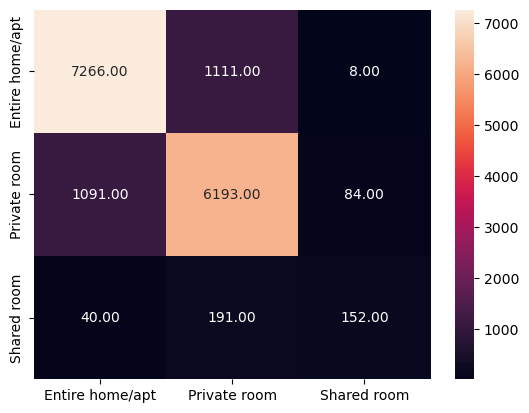

In [47]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

In [49]:
import joblib
joblib.dump(best_pipeline ,'Model_pipeline.pkl', compress= 3)

['Model_pipeline.pkl']

In [51]:
df_cleaned.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')